### Es 1
Hai a disposizione un file `data.csv` contenente dati mensili di traffico aereo con due colonne:

- `date`: data in formato `YYYY-MM` (mese/anno)
- `passengers`: numero di passeggeri per quel mese


Costruisci un modello di **regressione polinomiale** che approssima l’andamento del numero di passeggeri nel tempo.

1. Carica il dataset.
2. Convertilo in un formato numerico utilizzando una colonna `mese_numerico` che conti i mesi a partire da gennaio 1949.
3. Applica una regressione polinomiale (grado a tua scelta).
4. Calcola l’RMSE tra i valori reali e quelli predetti.
5. Visualizza i dati reali e la curva stimata con Plotly.

In [9]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
import plotly.graph_objects as go
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

df = pd.read_csv('../data.csv')
df.head()

,date,passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [10]:
df['mese_numerico'] = pd.to_datetime(df['date'])
df['mese_numerico'] = (df['mese_numerico'].dt.year - 1949) * 12 + (df['mese_numerico'].dt.month)
df.head()

,date,passengers,mese_numerico
0,1949-01,112,1
1,1949-02,118,2
2,1949-03,132,3
3,1949-04,129,4
4,1949-05,121,5


In [ ]:
X = df['mese_numerico'].values.reshape(-1, 1)
y = df["passengers"].values.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model_poly2 = make_pipeline(PolynomialFeatures(10), LinearRegression())
model_poly2.fit(X_train, y_train)
y_pred_poly2 = model_poly2.predict(X_test)


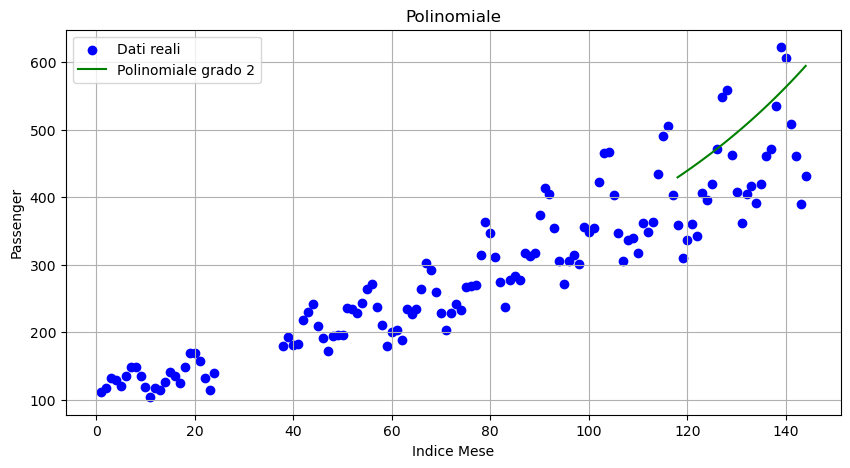

In [12]:
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X_test, y_pred_poly2, label=f"Polinomiale grado 2", color="green")
plt.xlabel("Indice Mese")
plt.ylabel("Passenger")
plt.title("Polinomiale")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
rmse =  root_mean_squared_error(y_test, y_pred_poly2)
print(rmse)




95.28366384579431


In [14]:
import plotly.express as px

df = pd.DataFrame({
    'x': X_test.flatten(),
    'reali': y_test.flatten(),
    'stimati': y_pred_poly2.flatten()
})

fig = px.scatter(df, x='x', y='reali', title='Dati reali vs stimati')
fig.add_scatter(x=df['x'], y=df['stimati'], mode='lines', name='Curva stimata')
fig.show()

